In [ ]:
from asset import Asset
from portfolio_old import Portfolio, efficient_frontier
%load_ext autoreload
%autoreload 2

Test del costruttore e del metodo di rappresentazione della classe.

In [3]:
import numpy as np
apple = Asset({'ticker': 'AAPL'})

In [4]:
apple.results()

,AAPL
Total return,6.579411
Annualized return,0.168518
Volatility,0.029086
Max Drawdown,1.703828
Historic VaR,0.029260


In [10]:
assets = [Asset({'ticker': 'AAPL'}), Asset({'ticker': 'JD'}), Asset({'ticker': 'MSTR'})]

In [6]:
p.daily_returns

,AAPL,EURUSD=X
Date,,
2003-12-02,-0.007862,0.010307
2003-12-03,-0.023961,0.002809
2003-12-04,0.005691,-0.003473
2003-12-05,-0.014288,0.008736
2003-12-08,0.009548,0.002709
...,...,...
2019-12-24,0.000950,0.001264
2019-12-26,0.019646,0.000477
2019-12-27,-0.000380,0.000510


In [7]:
p.weights

AAPL        0.5
EURUSD=X    0.5
dtype: float64

In [12]:
print(p.ptf_return)
print(p.ptf_volatility)

0.08221074971281013
0.011217170064821938


In [2]:
assets = [
    Asset({'ticker': 'AAPL'}),
    Asset({'ticker': 'JD'}),
    Asset({'ticker': 'MSTR'})
]

In [42]:
def minimize_vol(assets: list[Asset], target_return) -> Portfolio:
    """
    Funzione che, data una serie di assets e specificato un rendimento target, deve determinare i
    pesi necessari a comporre un portafoglio con gli stessi asset e che abbia il rendimento target.
    """

    print('Rendimento desiderato = ' + str(target_return))
    print('Numero di assets = ' + str(len(assets)))
    print('Rendimento guess iniziale (equally weighted) = ' + str(Portfolio(assets).ptf_return))
    print('Rendimento guess iniziale singoli asset = ' + str(Portfolio(assets).annualized_returns))

    init_guess = np.repeat(1/len(assets), len(assets))

    # constraint sui pesi che siano compresi tra 0 e 1
    bounds = ((0., 1.),)*len(assets)
    print("Bounds = " + str(bounds))

    # constraint sui pesi che sommino a 1
    weights_sum_to_1 = {
        'type': 'eq',
        'fun': lambda weights: np.sum(weights) - 1
    }

    # constraint sul rendimento che sia uguale a quello target
    return_is_target = {
        'type': 'eq',
        'fun': lambda weights: target_return - Portfolio(dict(zip(assets, weights))).ptf_return
    }

    # minimizziamo
    from scipy.optimize import minimize
    weights = minimize(
        lambda weights: Portfolio(dict(zip(assets, weights))).ptf_volatility,
        init_guess,
        method='SLSQP',
        options={'disp': False},
        constraints=(weights_sum_to_1,return_is_target),
        bounds=bounds
    )

    return Portfolio(dict(zip(assets, weights.x)))

def efficient_frontier(assets: list[Asset], n_samples: int) -> list[Portfolio]:
    """
    Funzione che deve restituire una lista di istanze di Portfolio (insieme di portafogli) ognuno
    dei quali a rendimento diverso abbia il set di pesi che minimizza la volatilità. Per farlo prende
    in input sempre la lista di asset dai quali vogliamo costruire i portafogli che stanno sulla
    frontiera efficiente. La lunghezza della lista va specificata qui con n_samples
    """

    # definizione della griglia dei rendimenti
    min_return = Portfolio(assets).annualized_returns.min() # partenza della griglia (minimo rendimento singolo asset)
    max_return = Portfolio(assets).annualized_returns.max() # arrivo della griglia (massimo rendimento singolo asset)
    target_returns = np.linspace(min_return, max_return, n_samples)

    # definizione dei portafoglio sulla frontiera efficiente
    portfolios = [minimize_vol(assets, target_return) for target_return in target_returns]
    return portfolios

eff_front = efficient_frontier(assets, 25)

Rendimento desiderato = 0.013935852194173428
Numero di assets = 3
Rendimento guess iniziale (equally weighted) = 0.09185786137176412
Rendimento guess iniziale singoli asset = AAPL    0.168518
JD      0.093120
MSTR    0.013936
dtype: float64
Bounds = ((0.0, 1.0), (0.0, 1.0), (0.0, 1.0))
Rendimento desiderato = 0.020376767088399167
Numero di assets = 3
Rendimento guess iniziale (equally weighted) = 0.09185786137176412
Rendimento guess iniziale singoli asset = AAPL    0.168518
JD      0.093120
MSTR    0.013936
dtype: float64
Bounds = ((0.0, 1.0), (0.0, 1.0), (0.0, 1.0))
Rendimento desiderato = 0.026817681982624908
Numero di assets = 3
Rendimento guess iniziale (equally weighted) = 0.09185786137176412
Rendimento guess iniziale singoli asset = AAPL    0.168518
JD      0.093120
MSTR    0.013936
dtype: float64
Bounds = ((0.0, 1.0), (0.0, 1.0), (0.0, 1.0))
Rendimento desiderato = 0.03325859687685065
Numero di assets = 3
Rendimento guess iniziale (equally weighted) = 0.09185786137176412
Rendime

Bounds = ((0.0, 1.0), (0.0, 1.0), (0.0, 1.0))
Bounds = ((0.0, 1.0), (0.0, 1.0), (0.0, 1.0))
Bounds = ((0.0, 1.0), (0.0, 1.0), (0.0, 1.0))
Bounds = ((0.0, 1.0), (0.0, 1.0), (0.0, 1.0))
Bounds = ((0.0, 1.0), (0.0, 1.0), (0.0, 1.0))
Bounds = ((0.0, 1.0), (0.0, 1.0), (0.0, 1.0))
Bounds = ((0.0, 1.0), (0.0, 1.0), (0.0, 1.0))
Bounds = ((0.0, 1.0), (0.0, 1.0), (0.0, 1.0))
Bounds = ((0.0, 1.0), (0.0, 1.0), (0.0, 1.0))
Bounds = ((0.0, 1.0), (0.0, 1.0), (0.0, 1.0))
Bounds = ((0.0, 1.0), (0.0, 1.0), (0.0, 1.0))
Bounds = ((0.0, 1.0), (0.0, 1.0), (0.0, 1.0))
Bounds = ((0.0, 1.0), (0.0, 1.0), (0.0, 1.0))
Bounds = ((0.0, 1.0), (0.0, 1.0), (0.0, 1.0))
Bounds = ((0.0, 1.0), (0.0, 1.0), (0.0, 1.0))
Bounds = ((0.0, 1.0), (0.0, 1.0), (0.0, 1.0))
Bounds = ((0.0, 1.0), (0.0, 1.0), (0.0, 1.0))
Bounds = ((0.0, 1.0), (0.0, 1.0), (0.0, 1.0))
Bounds = ((0.0, 1.0), (0.0, 1.0), (0.0, 1.0))
Bounds = ((0.0, 1.0), (0.0, 1.0), (0.0, 1.0))
Bounds = ((0.0, 1.0), (0.0, 1.0), (0.0, 1.0))
Bounds = ((0.0, 1.0), (0.0, 1.0), 

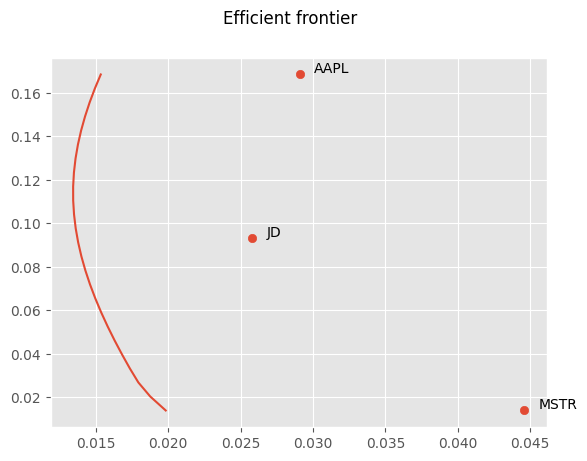

In [ ]:
# def plot_efficient_frontier(eff_front: list[Portfolio]):
#     import pandas as pd
#     returns = [ptf.ptf_return for ptf in eff_front]
#     volatilities = [ptf.ptf_volatility for ptf in eff_front]
#     ef = pd.DataFrame({
#         "Returns": returns, 
#         "Volatility": volatilities
#     })
#     return ef.plot.line(x="Volatility", y="Returns", style='.-', legend=False)

# plot_efficient_frontier(eff_front)

assets = [
    Asset({'ticker': 'AAPL'}),
    Asset({'ticker': 'JD'}),
    Asset({'ticker': 'MSTR'})
]
efficient_frontier(assets, 25)


In [1]:
from portfolio_old import Tickers, Portfolio
%load_ext autoreload
%autoreload 2

In [ ]:
p = Portfolio('msft aapl', period='max')
p.weights


[*********************100%***********************]  2 of 2 completed


MSFT    0.5
AAPL    0.5
dtype: float64

In [10]:
p.ptf_volatility

0.02035263909606558